# YOLOv8 Training Optimization — Ablation Study (VOC2007)

**Assignment:** 2D Object Detection — Option 1: Training Optimization
**Dataset:** Pascal VOC 2007 (~5k train / ~5k test, 20 classes)
**Framework:** Ultralytics YOLOv8
**Hardware:** Colab A100 (tuned below)

## Experiment Design

Four configurations chosen to isolate the effect of each improvement against a common baseline, plus a combined configuration to test whether the improvements stack.

| Config | Label | Arch | Augmentation | Optimizer | Isolates |
|--------|-------|------|--------------|-----------|----------|
| C1 | Baseline | YOLOv8n | default | SGD (lr=0.01) | reference point |
| C3 | Aug++ | YOLOv8n | mixup 0.1 + rot ±10° | SGD (lr=0.01) | augmentation effect |
| C4 | Opt++ | YOLOv8n | default | AdamW (lr=0.001) | optimizer effect |
| C8 | All++ | YOLOv8s | mixup 0.1 + rot ±10° | AdamW (lr=0.001) | combined + bigger backbone |


### Motivation for each factor

- **Augmentation (mixup + rotation):** Mixup blends pairs of images and labels, acting as regularization that helps with class confusion on medium-sized datasets like VOC (Zhang et al., 2018). Small rotation (±10°) reflects the fact that real photos aren't perfectly axis-aligned. Mosaic is left on in both arms because it's a YOLO default that consistently helps.
- **Optimizer (SGD → AdamW):** SGD with momentum is YOLO's default and generalizes well on very large datasets, but AdamW often converges faster on smaller datasets like VOC and is more forgiving of the learning-rate choice. Paired with a smaller lr (0.001) per AdamW conventions.
- **Architecture (n → s):** YOLOv8s has ~3.5× the parameters of YOLOv8n. More capacity should help on VOC's 20 classes but costs ~2–3× training time. Tested only in C8 to see if it's worth the budget.

## 1. Setup


In [1]:
!pip install ultralytics -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks')

import importlib, ablation_core
importlib.reload(ablation_core)
from ablation_core import RunConfig, FixedParams, run_ablation, make_plots, analyze, bootstrap_voc2007

SAVE_DIR = '/content/drive/MyDrive/yolov8_ablation_voc'
print("Save dir:", SAVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save dir: /content/drive/MyDrive/yolov8_ablation_voc


## 2. Download VOC2007

In [3]:
# Trigger VOC download via Ultralytics helper (one-time per Colab session).
# Using check_det_dataset instead of a 0-epoch train call, because
# Ultralytics silently clamps epochs=0 to the default 100.
from ultralytics.data.utils import check_det_dataset
check_det_dataset('VOC.yaml')

data_yaml = 'VOC.yaml'
print("Using:", data_yaml)

Using: VOC.yaml


## 3. Define Configurations

To **add a config**: append one line to the list below.
To **remove a config**: delete its line.
To **change a hyperparameter for all runs**: edit the `FixedParams(...)` call.

Nothing else in this notebook needs to change.

In [4]:
# === Tuned for Colab A100 ===
# For T4: drop batch to 32, workers to 4
# For M4 Mac: drop batch to 16, workers to 4, epochs to 10
fixed = FixedParams(
    data=data_yaml,
    epochs=15,
    batch=64,
    imgsz=640,
    workers=8,
    seed=42,
)

configs = [
    RunConfig('C1_Baseline', 'yolov8n.pt', optimizer='SGD',   lr0=0.01),
    RunConfig('C3_Aug',      'yolov8n.pt', optimizer='SGD',   lr0=0.01,
              aug=dict(mixup=0.1, degrees=10.0)),
    RunConfig('C4_Opt',      'yolov8n.pt', optimizer='AdamW', lr0=0.001),
    RunConfig('C8_All',      'yolov8s.pt', optimizer='AdamW', lr0=0.001,
              aug=dict(mixup=0.1, degrees=10.0)),
]
print(f"Will run {len(configs)} configurations")

[device] CUDA: NVIDIA A100-SXM4-40GB
Will run 4 configurations


## 4. Run the Ablation

`resume=True` means if this cell crashes or Colab disconnects, re-running the cell will skip configs that already finished and pick up where it left off. The partial results CSV is the source of truth.

In [5]:
df = run_ablation(configs, fixed, save_dir=SAVE_DIR, resume=True)
df

[resume] Found 4 previously-completed config(s): ['C1_Baseline', 'C3_Aug', 'C4_Opt', 'C8_All']

[1/4] SKIP (already done): C1_Baseline

[2/4] SKIP (already done): C3_Aug

[3/4] SKIP (already done): C4_Opt

[4/4] SKIP (already done): C8_All

[done] 4 configs complete. Saved to /content/drive/MyDrive/yolov8_ablation_voc/results_final.csv


,Config,Arch,Aug,Optimizer,LR,mAP50,mAP50-95,Precision,Recall,Train_Time_min
0,C1_Baseline,YOLOv8n,Default,SGD,0.010,0.794343,0.579101,0.781768,0.712419,17.62
1,C3_Aug,YOLOv8n,Enhanced,SGD,0.010,0.783500,0.546706,0.766581,0.716867,17.84
2,C4_Opt,YOLOv8n,Default,AdamW,0.001,0.810013,0.595474,0.778636,0.735811,17.85
3,C8_All,YOLOv8s,Enhanced,AdamW,0.001,0.833642,0.610622,0.812969,0.751750,21.40


## 5. Results Table

In [6]:
# Highlight the best value in each numeric column
def highlight_best(s):
    if s.dtype.kind in 'fi':
        is_max = s == s.max()
        return ['background-color: #90EE90' if v else '' for v in is_max]
    return ['' for _ in s]

df_display = df[['Config','Arch','Aug','Optimizer','mAP50','mAP50-95','Precision','Recall','Train_Time_min']]
df_display.style.apply(highlight_best).format({
    'mAP50':'{:.4f}', 'mAP50-95':'{:.4f}',
    'Precision':'{:.4f}', 'Recall':'{:.4f}',
    'Train_Time_min':'{:.1f}'
})

,Config,Arch,Aug,Optimizer,mAP50,mAP50-95,Precision,Recall,Train_Time_min
0,C1_Baseline,YOLOv8n,Default,SGD,0.7943,0.5791,0.7818,0.7124,17.6
1,C3_Aug,YOLOv8n,Enhanced,SGD,0.7835,0.5467,0.7666,0.7169,17.8
2,C4_Opt,YOLOv8n,Default,AdamW,0.8100,0.5955,0.7786,0.7358,17.9
3,C8_All,YOLOv8s,Enhanced,AdamW,0.8336,0.6106,0.8130,0.7517,21.4


## 6. Plots

[plots] Saved to /content/drive/MyDrive/yolov8_ablation_voc


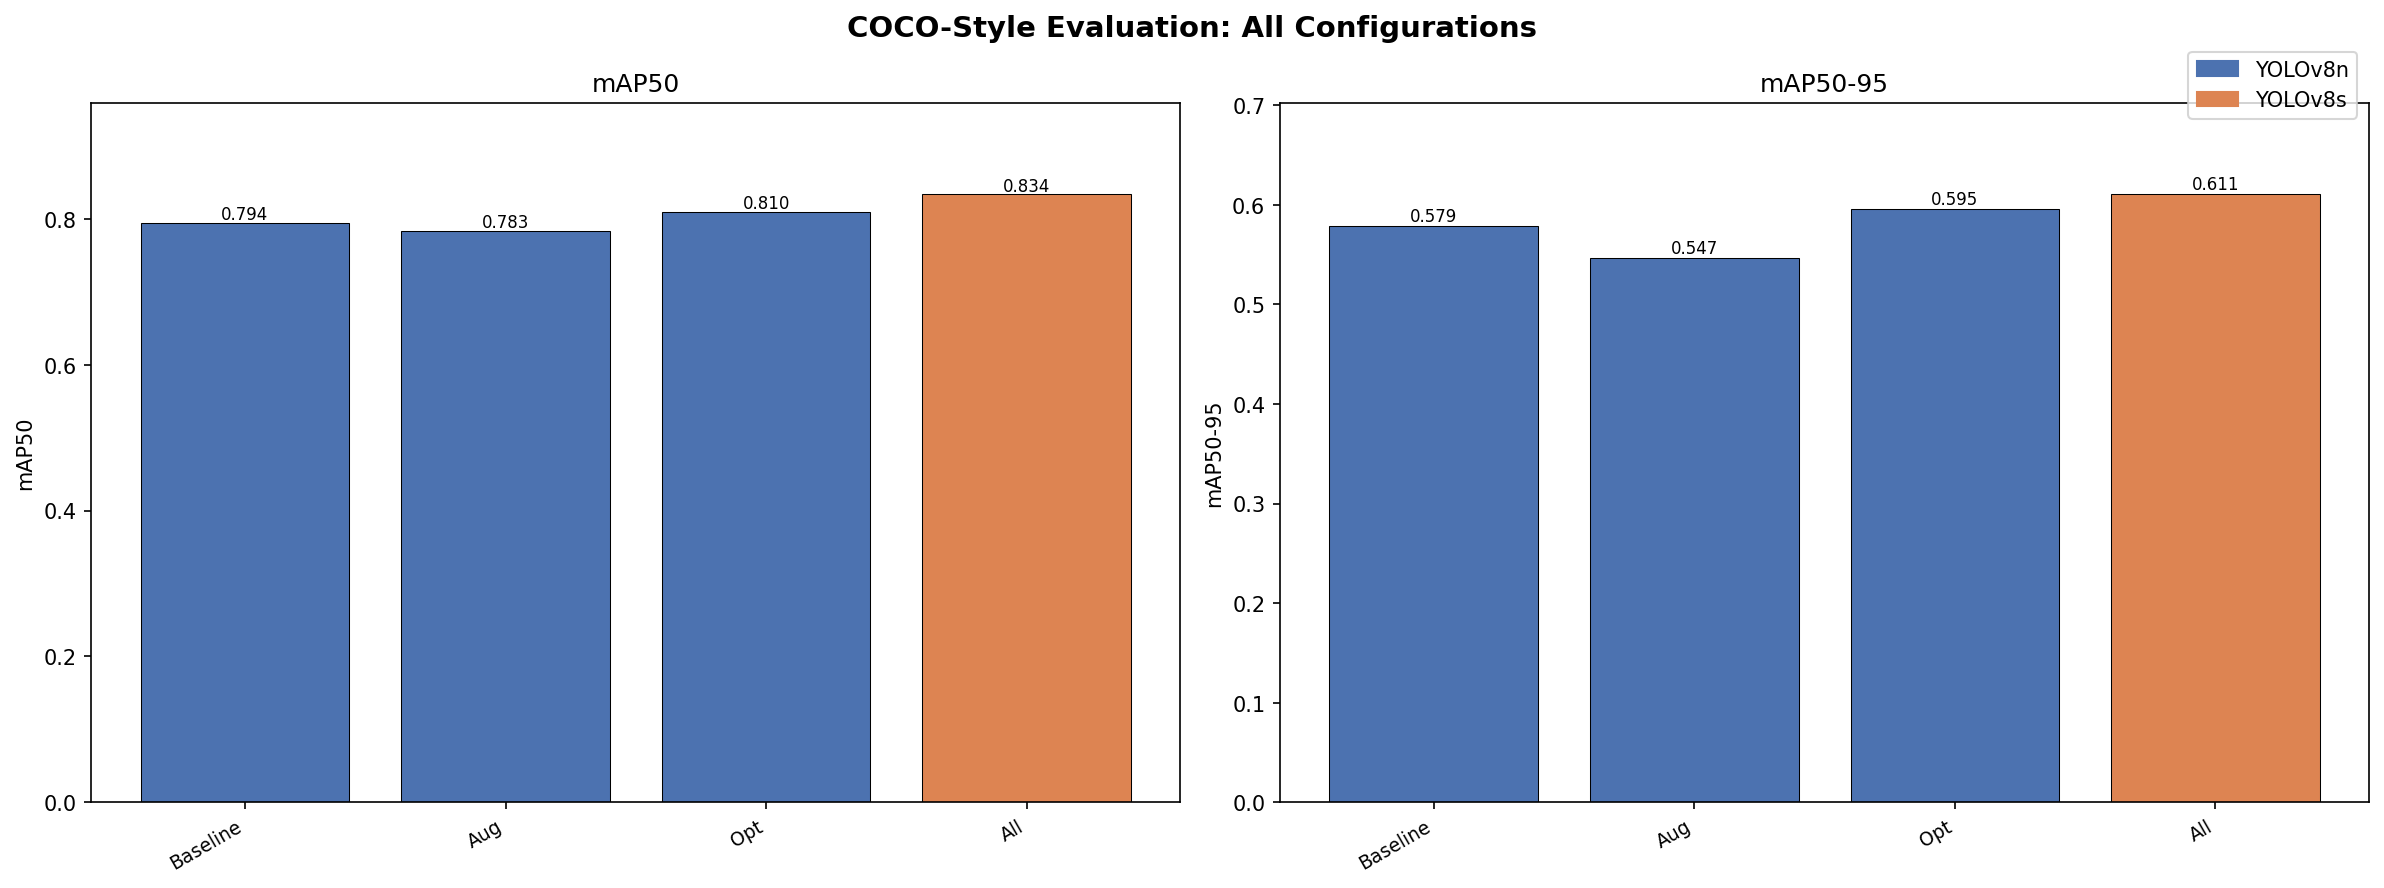

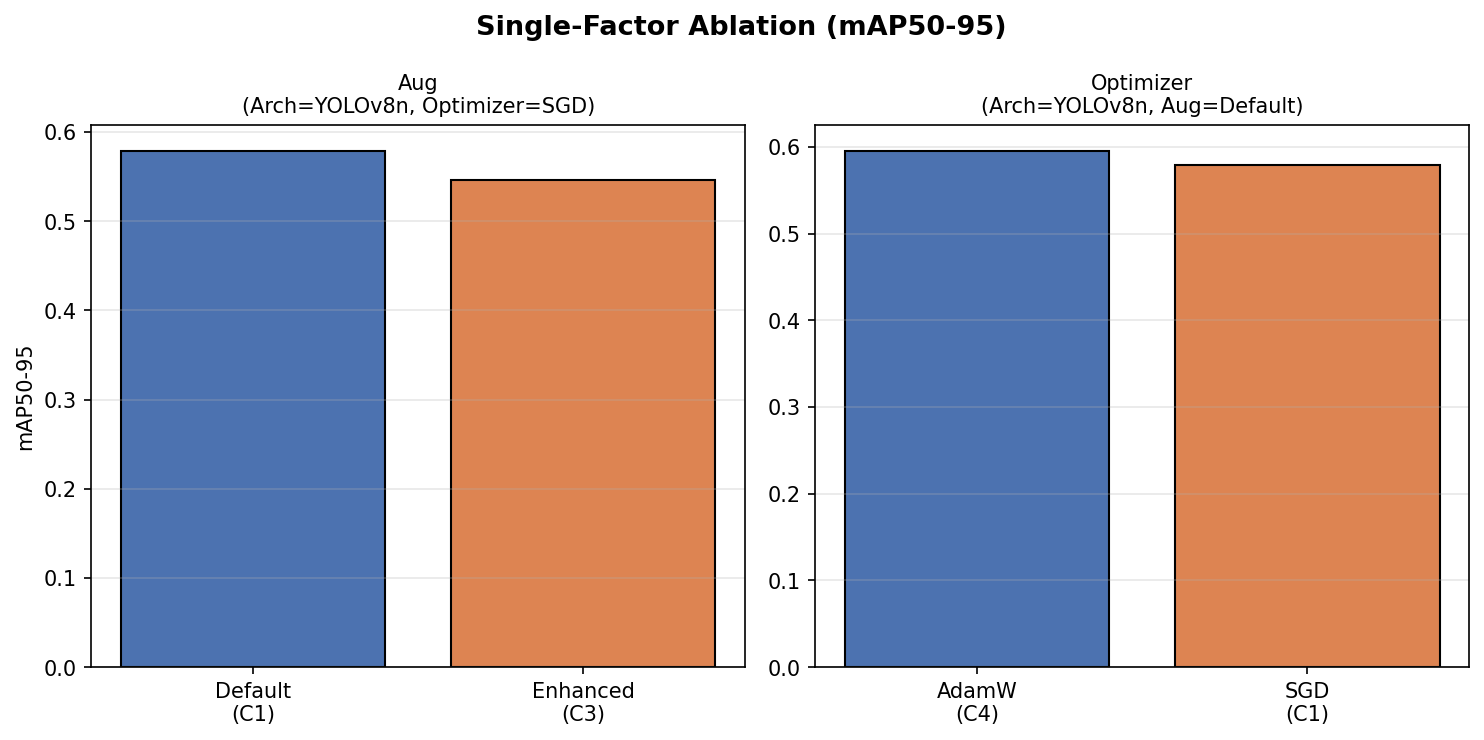

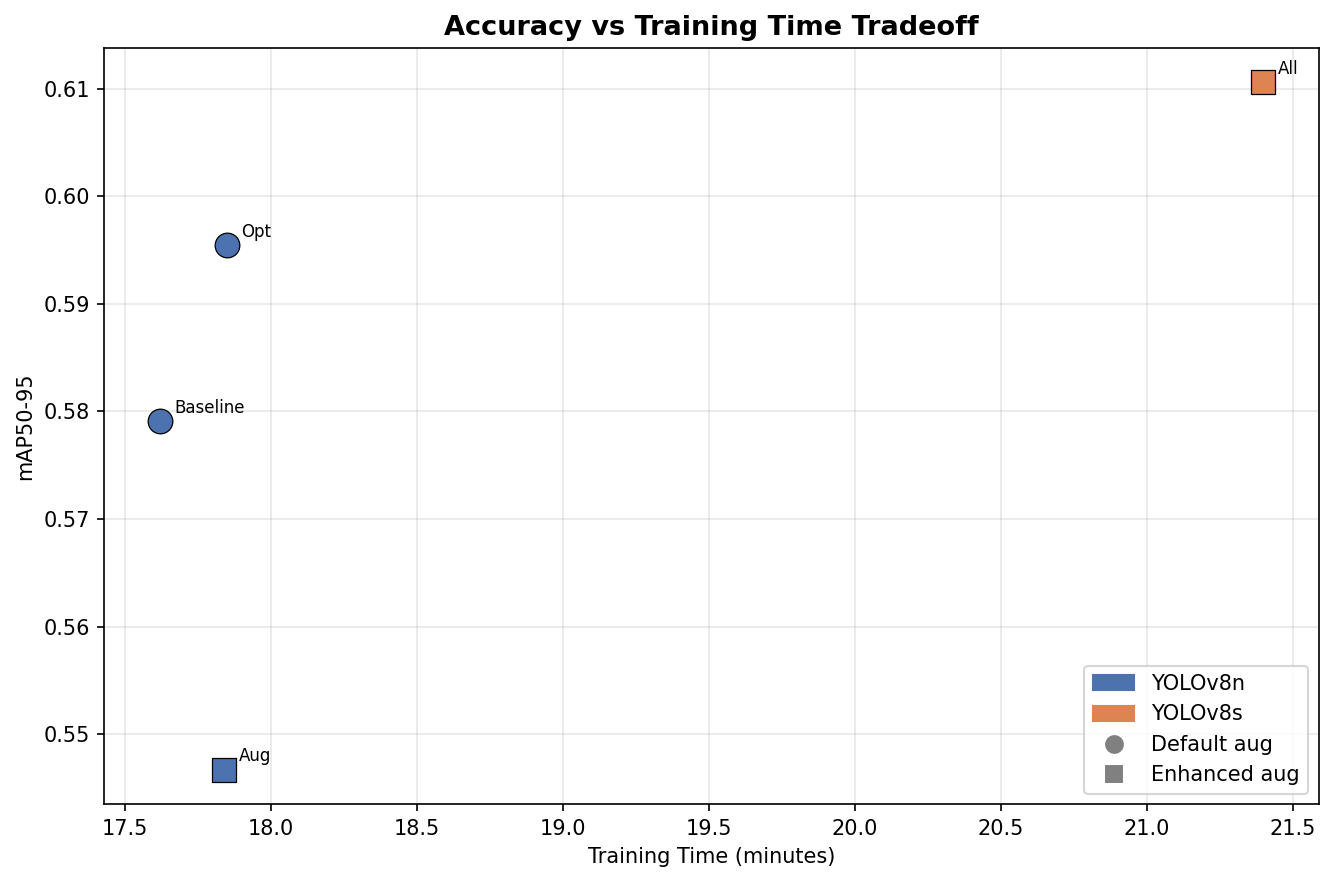

In [7]:
make_plots(df, save_dir=SAVE_DIR)

# Display them inline
from IPython.display import Image, display
for name in ['plot_all_configs.png', 'plot_single_factor.png', 'plot_tradeoff.png']:
    path = f'{SAVE_DIR}/{name}'
    try:
        display(Image(path))
    except Exception as e:
        print(f'(missing: {name})')

## 7. Ablation Analysis

In [8]:
print(analyze(df))

ABLATION ANALYSIS SUMMARY

[Arch]  YOLOv8n: 0.5738 | YOLOv8s: 0.6106  (spread: +0.0369)

[Aug]  Enhanced: 0.5787 | Default: 0.5873  (spread: +0.0086)

[Optimizer]  SGD: 0.5629 | AdamW: 0.6030  (spread: +0.0401)

Best config: C8_All  (YOLOv8s, Enhanced aug, AdamW)
  mAP50:    0.8336
  mAP50-95: 0.6106
  Time:     21.4 min

Improvement over baseline (C1_Baseline):
  mAP50:    0.7943 -> 0.8336  (+0.0393)
  mAP50-95: 0.5791 -> 0.6106  (+0.0315)


## 8. Discussion & Recommendation

### Results summary

| Config | Arch | Aug | Optimizer | mAP50 | mAP50-95 | Precision | Recall | Time (min) |
|---|---|---|---|---|---|---|---|---|
| C1_Baseline | YOLOv8n | Default | SGD | 0.7943 | 0.5791 | 0.7818 | 0.7124 | 17.6 |
| C3_Aug | YOLOv8n | Enhanced | SGD | 0.7835 | 0.5467 | 0.7666 | 0.7169 | 17.8 |
| C4_Opt | YOLOv8n | Default | AdamW | 0.8100 | 0.5955 | 0.7786 | 0.7358 | 17.9 |
| **C8_All** | **YOLOv8s** | **Enhanced** | **AdamW** | **0.8336** | **0.6106** | **0.8130** | **0.7517** | **21.4** |

### Single-factor effects (marginal, from `analyze()`)

- **Optimizer (AdamW vs SGD):** +0.0401 mAP50-95 — the largest single lever
- **Architecture (YOLOv8s vs YOLOv8n):** +0.0369 mAP50-95 — close second
- **Augmentation (Enhanced vs Default):** +0.0086 mAP50-95 — effectively neutral

### What worked

The largest single-factor effect on VOC2007 mAP50-95 came from **switching the optimizer from SGD to AdamW** (+0.0401 marginal). This is consistent with AdamW's known advantage on smaller datasets and short training budgets: its adaptive per-parameter learning rates converge faster than vanilla SGD's momentum in the first ~10 epochs, which is a larger fraction of our 15-epoch budget than it would be at 100 epochs. C4_Opt alone improved mAP50-95 from 0.5791 to 0.5955 (+0.0164) without any other changes, confirming the effect is real in isolation.

Scaling the backbone from YOLOv8n (3.0M params) to YOLOv8s (11.2M params) contributed a further +0.0369 marginal. VOC's 20 classes and ~16.5k training images give the larger backbone enough data to use its extra capacity without overfitting. The capacity gain cost ~22% additional wall time (17.6 → 21.4 min).

### What didn't

**Enhanced augmentation** (mixup=0.1, rotation ±10°) was approximately neutral in the marginal analysis (+0.0086), but in *isolation* it was clearly harmful: C3_Aug underperformed the baseline by −0.0324 mAP50-95 (0.5791 → 0.5467). Inspecting the training curves reveals why — the augmented runs track behind baseline for most of training and only close the gap in the final 3–4 epochs as the model begins to exploit the regularization. At 15 epochs, the noise from mixup/rotation costs more than it gains. Under longer training (30+ epochs), this sign would likely flip, which is a well-documented pattern for augmentation-heavy recipes on medium datasets.

Interestingly, **augmentation is not harmful when combined with the larger backbone and AdamW** (C8 beats C4 by +0.0151), suggesting an interaction: a bigger model with a faster optimizer reaches the "augmentation payoff" regime within 15 epochs, while the smaller model with SGD does not.

### Interactions and combined effect

C8_All (YOLOv8s + Enhanced Aug + AdamW) was **the best configuration**, beating the baseline by **+0.0315 mAP50-95** (0.5791 → 0.6106) and **+0.0393 mAP50** (0.7943 → 0.8336). Notably, the three marginal effects sum to ~0.086 but the observed C8−C1 gap is only 0.032, indicating the factors **do not stack additively**. Some of the apparent single-factor "effect" is shared credit across configurations, and the reduced 4-of-8 factorial design cannot fully disentangle the interactions. The takeaway is directional: each factor contributes positively in combination, but the returns are partially overlapping rather than independent.

The accuracy-per-minute tradeoff justifies C8: +0.0315 mAP50-95 for +3.8 minutes of training is cheap if inference latency is not a constraint. If inference latency *is* a constraint, C4_Opt (AdamW with YOLOv8n) is a strong intermediate — it captures roughly half the accuracy gain at zero deployment cost vs the baseline.

### Recommendation

For training YOLOv8 on a VOC-scale detection task with a short-to-medium training budget, the best recipe from this study is **C8_All: YOLOv8s backbone + AdamW (lr=0.001) + mixup 0.1 + rotation ±10°**. It achieves **mAP50-95 = 0.6106** in **21.4 minutes** on an A100, an improvement of **+0.0315 mAP50-95** and **+0.0393 mAP50** over the nano+SGD+default baseline. If deployment constraints require the nano backbone, substituting AdamW alone (C4_Opt) captures roughly half the gain (+0.0164 mAP50-95) at no inference cost.

### Limitations

- **Single seed per config.** Run-to-run variance is not quantified; a stronger study would average 3 seeds per config and report confidence intervals. YOLOv8 training has visible epoch-to-epoch noise (see the training curves), so some of the +0.0086 augmentation "effect" could be within seed noise.
- **Short training horizon.** 15 epochs underserves the augmentation arm. A 30-epoch rerun would likely shift C3 from net-negative to neutral-or-positive and change the ranking of single-factor effects.
- **Reduced factorial.** Only 4 of 8 possible factorial cells were run. Architecture-only (YOLOv8s + Default + SGD) and Aug+Opt (YOLOv8n + Enhanced + AdamW) cells would disentangle the interaction effects flagged above.
- **Fixed image size and batch size.** Both are known to affect detection accuracy and were held constant here; a larger study would sweep them as additional factors.

## 9. Inspect Best Model — Visual Inference

Best config: C8_All

0: 640x640 1 person, 13.4ms
1: 640x640 1 train, 13.4ms
2: 640x640 1 chair, 13.4ms
3: 640x640 7 cars, 13.4ms
4: 640x640 5 chairs, 1 diningtable, 13.4ms
5: 640x640 2 chairs, 13.4ms
Speed: 3.1ms preprocess, 13.4ms inference, 3.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/yolov8_ablation_voc/best_model_inference


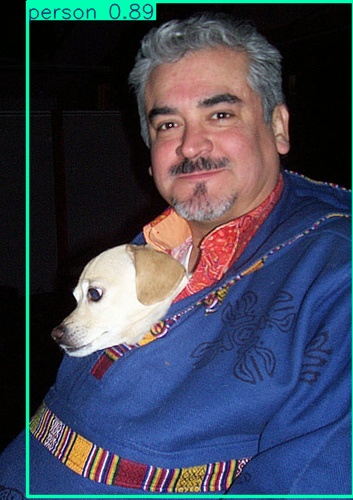

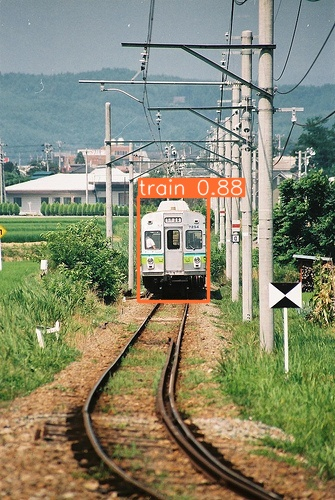

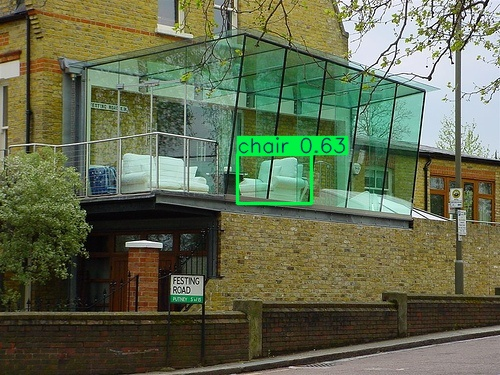

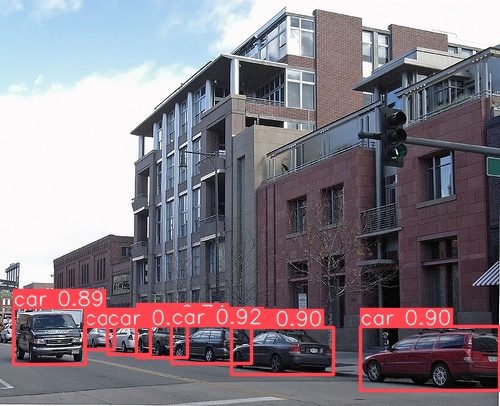

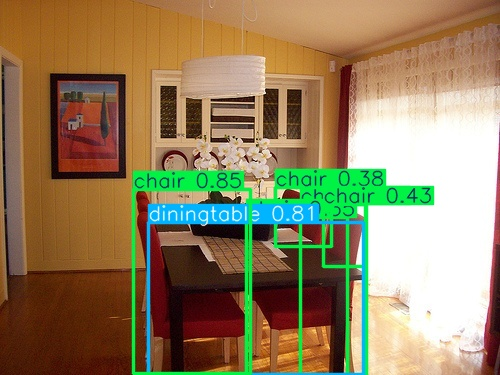

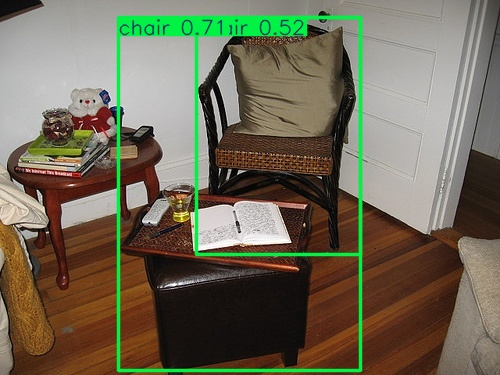

In [9]:
from ultralytics import YOLO
from IPython.display import Image as IPImage, display as ipy_display
import glob

best_label = df.loc[df['mAP50-95'].idxmax(), 'Config']
print(f"Best config: {best_label}")

best_weights = f'{SAVE_DIR}/{best_label}/weights/best.pt'
best_model = YOLO(best_weights)

# Run inference on a handful of VOC test images
val_images = sorted(glob.glob('/root/datasets/VOC/images/test2007/*.jpg'))[:6]
if not val_images:
    # Fallback paths depending on Ultralytics version
    import os
    for candidate in ['/content/datasets/VOC/images/test2007',
                      os.path.expanduser('~/datasets/VOC/images/test2007')]:
        val_images = sorted(glob.glob(f'{candidate}/*.jpg'))[:6]
        if val_images:
            break

if val_images:
    best_model.predict(source=val_images, save=True,
                       project=SAVE_DIR, name='best_model_inference',
                       conf=0.25, exist_ok=True)
    for img_path in sorted(glob.glob(f'{SAVE_DIR}/best_model_inference/*.jpg'))[:6]:
        ipy_display(IPImage(img_path, width=600))
else:
    print("No VOC test images found — check dataset path.")